In [ ]:
from google.colab import files
files.upload()

Saving income_random_forest.csv to income_random_forest.csv
Saving heart_stacking.csv to heart_stacking.csv
Saving fraud_smote.csv to fraud_smote.csv
Saving churn_boosting.csv to churn_boosting.csv
Saving diabetes_bagging.csv to diabetes_bagging.csv


{'income_random_forest.csv': b'Age,EducationYears,HoursPerWeek,Experience,Income\n37,12,44,12,0\n46,19,58,33,1\n53,10,54,24,0\n46,11,22,6,0\n36,17,56,3,1\n62,13,49,7,1\n63,19,57,19,1\n43,15,53,28,1\n44,8,31,9,0\n26,17,38,33,0\n25,15,56,25,1\n43,18,36,2,0\n52,14,29,5,0\n48,8,31,4,0\n62,9,35,4,0\n41,10,43,22,0\n45,8,38,8,0\n47,16,27,34,0\n40,15,50,19,1\n26,9,40,34,0\n36,16,36,17,0\n39,14,42,16,1\n60,16,56,23,1\n39,13,35,2,0\n41,13,25,31,0\n47,18,27,34,0\n59,11,44,37,0\n26,17,37,12,0\n20,17,44,24,1\n51,9,31,8,0\n32,14,34,3,0\n49,12,45,13,0\n42,18,45,36,1\n38,13,51,33,1\n51,9,29,10,0\n49,12,35,2,0\n48,17,26,27,0\n64,11,36,28,0\n48,16,42,8,1\n49,13,45,2,1\n35,9,40,24,0\n59,8,41,33,0\n38,12,26,11,0\n37,16,33,8,0\n20,13,34,14,0\n33,17,26,39,0\n21,19,28,24,0\n47,14,27,4,0\n49,12,42,10,0\n57,17,48,33,1\n23,13,37,23,0\n20,12,50,14,0\n27,18,49,37,1\n48,16,58,7,1\n58,13,54,4,1\n22,18,37,25,0\n51,15,58,17,1\n29,9,36,5,0\n29,19,33,36,0\n38,16,50,12,1\n53,12,43,27,0\n52,14,54,4,1\n42,17,53,12,1\n47,8

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error
import numpy as np

from imblearn.over_sampling import SMOTE
print("SUBASRI R 24BAD116")

SUBASRI R 24BAD116


Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


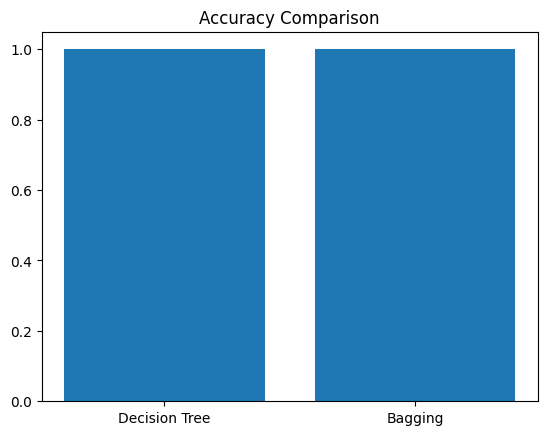

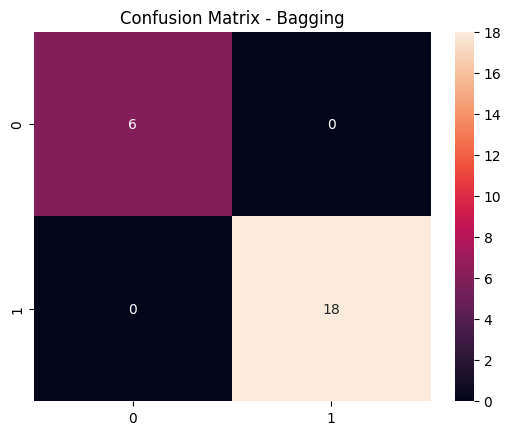

Decision Tree RMSE: 0.0
Bagging RMSE: 0.0


In [ ]:
# Load dataset
df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Visualization
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt="d")
plt.title("Confusion Matrix - Bagging")
plt.show()

# Calculate MSE first
mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_bag = mean_squared_error(y_test, y_pred_bag)

# Calculate RMSE
rmse_dt = np.sqrt(mse_dt)
rmse_bag = np.sqrt(mse_bag)

print("Decision Tree RMSE:", rmse_dt)
print("Bagging RMSE:", rmse_bag)

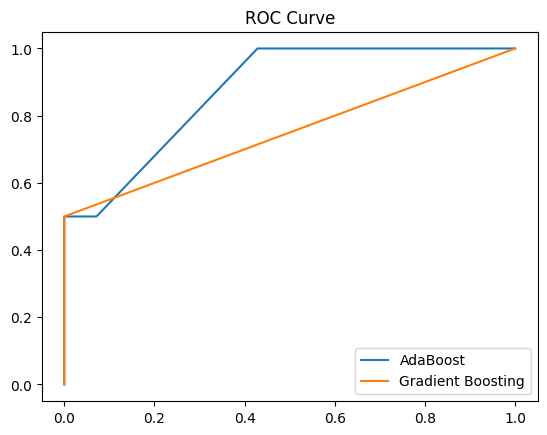

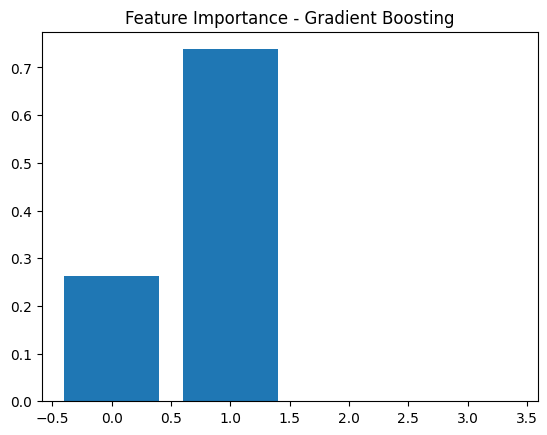

In [ ]:
df = pd.read_csv("churn_boosting.csv")

# Preprocessing
df.dropna(inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# AdaBoost
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# ROC Curve
for model, name in [(ada, "AdaBoost"), (gb, "Gradient Boosting")]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance
plt.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

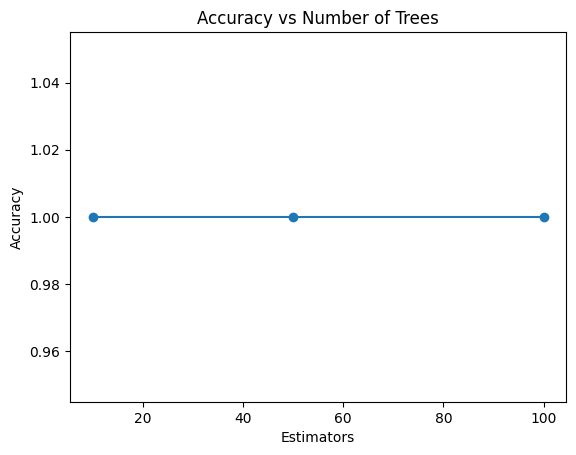

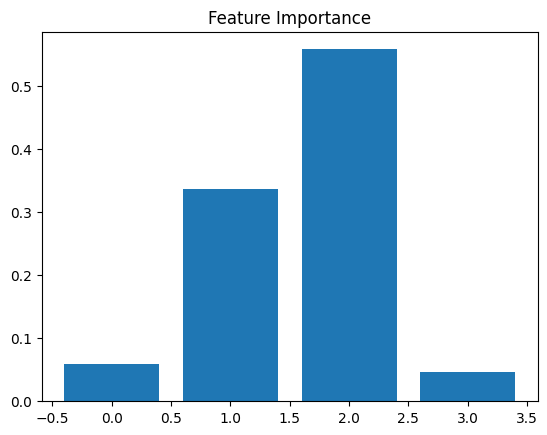

Trees: 100, RMSE: 0.0


In [ ]:
df = pd.read_csv("income_random_forest.csv")

# Preprocessing
df.dropna(inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Tune estimators
estimators = [10, 50, 100]
acc_list = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc_list.append(accuracy_score(y_test, y_pred))

# Plot accuracy vs trees
plt.plot(estimators, acc_list, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Estimators")
plt.ylabel("Accuracy")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(range(len(rf.feature_importances_)), rf.feature_importances_)
plt.title("Feature Importance")
plt.show()
# Inside your loop for estimators:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Trees: {n}, RMSE: {rmse}")

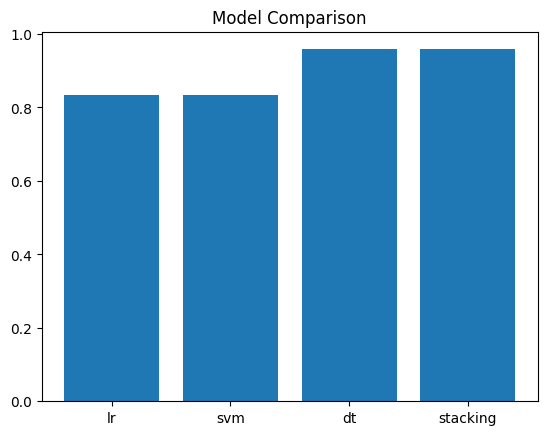

In [ ]:
df = pd.read_csv("heart_stacking.csv")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Base models
models = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("svm", SVC(probability=True)),
    ("dt", DecisionTreeClassifier())
]

# Stacking
stack = StackingClassifier(estimators=models, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

# Individual models accuracy
results = {}

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Stacking accuracy
y_pred_stack = stack.predict(X_test)
results["stacking"] = accuracy_score(y_test, y_pred_stack)

# Plot
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.show()

Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64


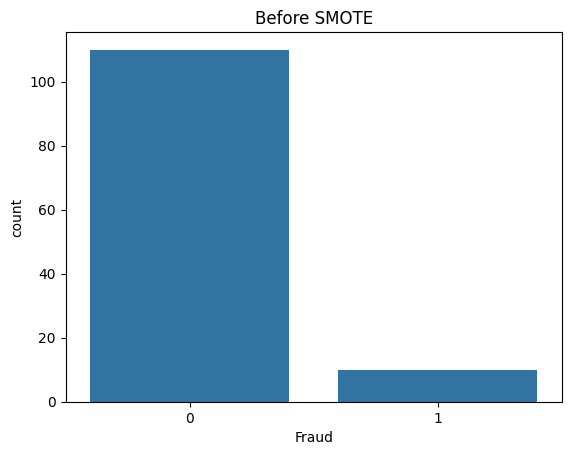

After SMOTE:
 Fraud
0    110
1    110
Name: count, dtype: int64


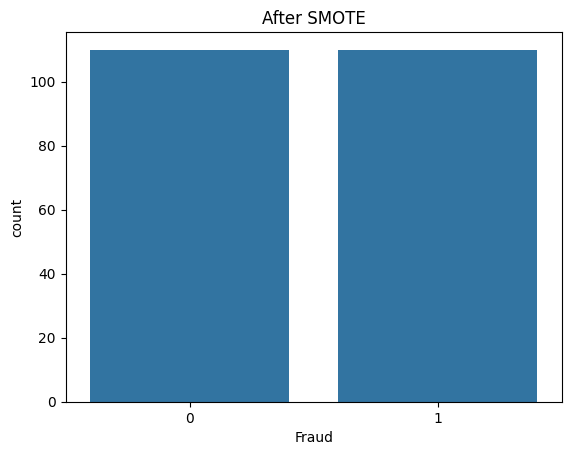

Before SMOTE Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        26
           1       0.00      0.00      0.00         4

    accuracy                           0.87        30
   macro avg       0.43      0.50      0.46        30
weighted avg       0.75      0.87      0.80        30

After SMOTE Report
              precision    recall  f1-score   support

           0       0.76      0.73      0.75        26
           1       0.77      0.79      0.78        29

    accuracy                           0.76        55
   macro avg       0.76      0.76      0.76        55
weighted avg       0.76      0.76      0.76        55



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


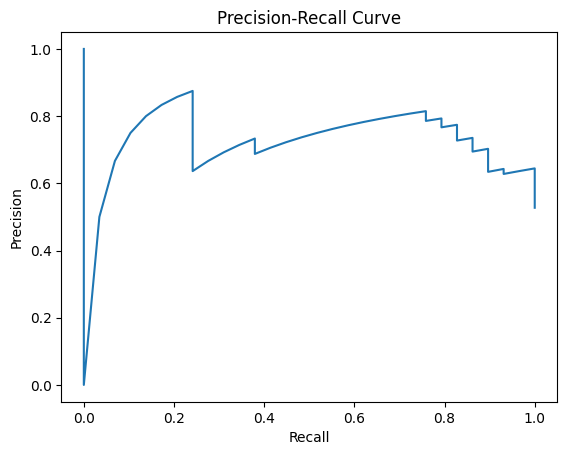

In [ ]:
df = pd.read_csv("fraud_smote.csv")

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

# Before SMOTE
print("Before SMOTE:\n", y.value_counts())

# Plot before
sns.countplot(x=y)
plt.title("Before SMOTE")
plt.show()

# Apply SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

# Plot after
sns.countplot(x=y_res)
plt.title("After SMOTE")
plt.show()

# Train model before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Before SMOTE Report")
print(classification_report(y_test, y_pred))

# Train after SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("After SMOTE Report")
print(classification_report(y_test, y_pred))

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()